In [3]:
# imports
import dxpy
import pandas as pd
import numpy as np

# Splitting Data
from sklearn.model_selection import train_test_split

# visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Read file

In [4]:
# Download the file
dxpy.download_dxfile('file-GpF95fjJjKXK3yfQv53Pg9Z0', 'file.csv')

In [5]:
# Read file to dataframe
df = pd.read_csv('file.csv', sep='\t')

In [ ]:
# First 5 rows of dataframe
df.head()

In [7]:
df.drop(columns=['eid'], inplace=True)

In [ ]:
df.head()

In [9]:
# Shape of the dataframe
df.shape

(17684, 2923)

In [10]:
df.isna().sum()

status         0
alcam        281
lilrb5       281
lilrb1       281
ccl15        281
            ... 
endou       4020
ctss        4177
cst1        4838
UKBB_GRS      19
grs            0
Length: 2923, dtype: int64

# Number of cases and controls

In [11]:
# Distribution of the target variable
df['status'].value_counts()

0    16331
1     1353
Name: status, dtype: int64

In [20]:
# Calculate the percentage
df['status'].value_counts(normalize=True) * 100

0    92.349016
1     7.650984
Name: status, dtype: float64

In [12]:
# Split data to input and output
X = df.drop(columns=['status'])
y = df['status']

In [13]:
# Split data to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
# Counting the number of cases (1) and controls (0) in train set
y_train.value_counts()

0    13065
1     1082
Name: status, dtype: int64

In [22]:
# Counting the number of cases (1) and controls (0) in test set
y_test.value_counts()

0    3266
1     271
Name: status, dtype: int64

In [23]:
# Calculate the percentage
y_train.value_counts(normalize=True) * 100

0    92.351735
1     7.648265
Name: status, dtype: float64

In [24]:
# Calculate the percentage
y_test.value_counts(normalize=True) * 100

0    92.33814
1     7.66186
Name: status, dtype: float64

# Descriptive statistics

In [10]:
# Information about the dasaset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17684 entries, 0 to 17683
Columns: 2923 entries, status to grs
dtypes: float64(2922), int64(1)
memory usage: 394.4 MB


In [12]:
# Summary statistics for grs
print(df['grs'].describe())

count    17684.000000
mean        -3.250011
std          1.386395
min         -8.263278
25%         -4.170412
50%         -3.258935
75%         -2.349110
max          2.455282
Name: grs, dtype: float64


In [13]:
# Summary statistics for grs
print(df['UKBB_GRS'].describe())

count    17665.000000
mean        -0.118515
std          0.958893
min         -4.257570
25%         -0.764209
50%         -0.115758
75%          0.530357
max          3.562840
Name: UKBB_GRS, dtype: float64


In [14]:
# Summary statistics for PROTEINS
print(df.iloc[:, 1:2921].describe())

              alcam        lilrb5        lilrb1         ccl15         ccl16  \
count  17403.000000  17403.000000  17403.000000  17403.000000  17403.000000   
mean       0.074825     -0.176416      0.030526      0.043890     -0.195213   
std        0.223381      0.802352      0.311654      0.492336      0.595011   
min       -0.988300     -3.516900     -1.550750     -1.322400     -4.495800   
25%       -0.068150     -0.500350     -0.173250     -0.285700     -0.522800   
50%        0.070650     -0.024400      0.032650     -0.040900     -0.141000   
75%        0.212175      0.413900      0.235875      0.270350      0.175975   
max        2.132300      2.056000      2.249550      4.266600      4.043500   

             tgfbr3      adamts13          cdh5        igfbp7         icam3  \
count  17403.000000  17403.000000  17403.000000  17403.000000  17403.000000   
mean       0.003128      0.014928      0.012728     -0.029466      0.011826   
std        0.362665      0.255960      0.336818    

# Plots

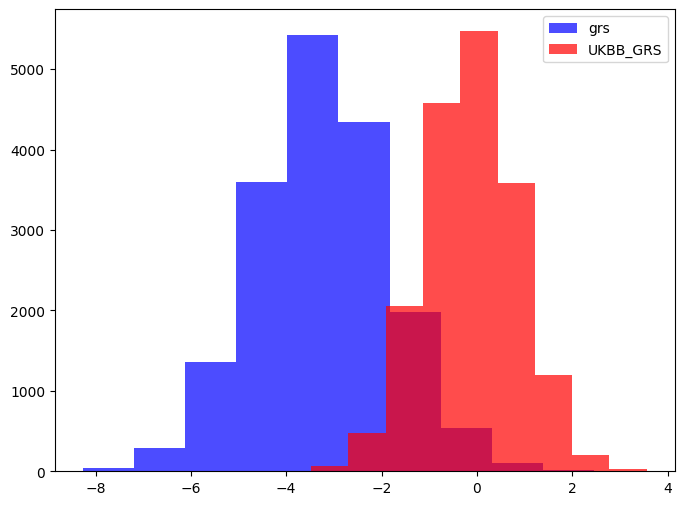

In [15]:
plt.figure(figsize=(8,6))
plt.hist(df['grs'], color='blue', label='grs', alpha=0.7)
plt.hist(df['UKBB_GRS'], color='red', label='UKBB_GRS', alpha=0.7)
plt.legend()

# save plot
#plt.savefig('GRSs', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

In [16]:
# Calculate the mean of proteins
proteins_means = df.iloc[:, 1:2921].mean()

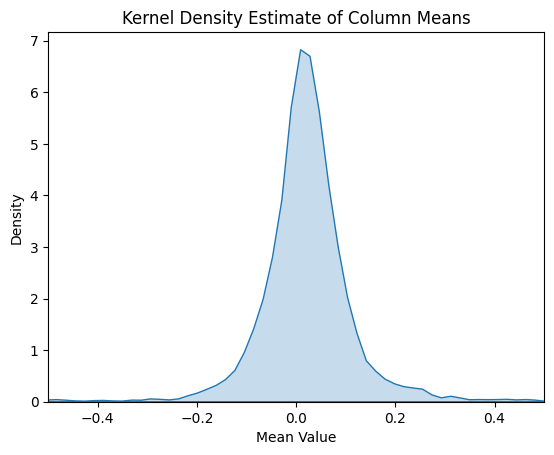

In [17]:
# Plotting the mean values using a Gaussian KDE
sns.kdeplot(proteins_means, bw_adjust=0.5, fill=True)

plt.title('Kernel Density Estimate of Column Means')
plt.xlabel('Mean Value')
plt.ylabel('Density')
plt.xlim(-0.5, 0.5)
plt.show()

In [18]:
# Calculate the median of proteins
proteins_median = df.iloc[:, 1:2921].median()

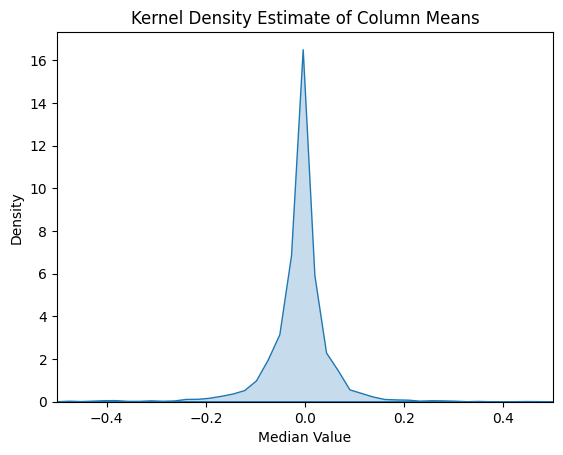

In [19]:
# Plotting the mean values using a Gaussian KDE
sns.kdeplot(proteins_median, bw_adjust=0.5, fill=True)

plt.title('Kernel Density Estimate of Column Means')
plt.xlabel('Median Value')
plt.ylabel('Density')
plt.xlim(-0.5, 0.5)
plt.show()

# Correlation with status

In [20]:
# Calculate the correlation of all features with 'status'
correlation_with_status = df.corr()['status']

In [27]:
sorted_correlation = correlation_with_status.reindex(correlation_with_status.abs().sort_values(ascending=False).index)

In [28]:
sorted_correlation

status      1.000000
grs        -0.173404
UKBB_GRS   -0.165969
paep       -0.101446
fshb        0.099555
              ...   
prkar1a     0.000040
lxn         0.000021
tmed1      -0.000017
lto1       -0.000014
gbp2        0.000008
Name: status, Length: 2923, dtype: float64

In [29]:
sorted_correlation.to_csv('corr.csv', sep='\t')